# Práctica 2 - Ejercicio 2

Asignatura: Programación para la Inteligencia Artificial

Alumno: Fernández Roldán, Daniel

Este es el segundo ejercicio de la Práctica 2 de Programación para la Inteligencia Artificial. Este ejercicio se debe entregar en un cuaderno de Jupyter separado del primero.

CIFAR100 es un conjunto de datos con dos niveles de etiquetado. Un etiquetado *fino* con 100 clases y un etiquetado *grueso* con 20 superclases. Se desea un sistema basado en neuronas lineales que tenga capacidad para realizar el etiquetado *fino*, pero se propone estudiar si la información que da el etiquetado *grueso* puede ayudar en la tarea aprovechando la probabilidad condicionada:

$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

Se espera una comparación entre la aproximación que usa solo un modelo neuronal para el etiquetado *fino* y la aproximación que incluye información del etiquetado *grueso*.

Información del conjunto de datos:

https://www.cs.toronto.edu/~kriz/cifar.html

Se espera el uso de las herramientas pertinentes tanto para completar el código como para realizar experimentos de los que se puedan extraer conclusiones sobre la capacidad del modelo entrenado. En el cuaderno se deben incluir los experimentos más relevantes.

Como conjunto de test se debe usar el conjunto de test íntegro que provee el conjunto de datos.

El cuaderno entregado debe llamarse ApellidosNombrePractica2Ejercicio2.ipynb

Consejos:
*  Cambiar el optimizador SGD por Adam. Lo veremos en clase próximamente :)
*  Normalizar los colores de las imágenes al rango [0,1].

In [10]:
# Import libraries.
import torch
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision import datasets, transforms

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

from tqdm import tqdm

import matplotlib.pyplot as plt

In [11]:
# Define the transformation to convert images to tensors and normalize them.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load the CIFAR-100 dataset for training and testing with the specified transformation. (Original Datasets)
train_dataset_full = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

# Split the full training dataset into training and validation sets (80% training, 20% validation).
train_size = int(0.8 * len(train_dataset_full))  # Calculate the size of the training set (80% of the full dataset).
val_size = len(train_dataset_full) - train_size  # Calculate the size of the validation
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])  # Split the full training dataset into training and validation sets.

# Create data loaders for the training, validation, and test datasets with specified batch sizes and other parameters.
# batch_size=64 means that each batch will contain 64 images, shuffle=True randomizes the order of the data for training, and shuffle=False keeps the order for validation and testing.
# shuffle=True is used for the training dataset to ensure that the model does not learn the order of the data, which can help improve generalization. For validation and test datasets, shuffle=False is used to maintain a consistent order for evaluation.
# num_workers=4 allows for parallel data loading, and pin_memory=True speeds up data transfer to GPU.
# pin_memory=True is beneficial when using a GPU, as it allows for faster data transfer from CPU to GPU memory.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

# Print the number of images in the training, validation, and test datasets.
print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Test images (Final exam): {len(test_dataset)}")

# Get a batch of images and labels from the training data loader.
images, fine_labels = next(iter(train_loader))

# Define the mapping from fine labels to coarse labels.
coarse_mapping = torch.tensor([
    4, 1, 14, 8, 0, 6, 7, 7, 18, 3, 3, 14, 9, 18, 7, 11, 3, 9, 7, 11,
    6, 11, 5, 10, 7, 6, 13, 15, 3, 15, 0, 11, 1, 10, 12, 14, 16, 9, 11, 5,
    5, 19, 8, 8, 15, 13, 14, 17, 18, 10, 16, 4, 17, 4, 2, 0, 17, 4, 18, 17,
    10, 3, 2, 12, 12, 16, 12, 1, 9, 19, 2, 10, 0, 1, 16, 12, 9, 13, 15, 13,
    16, 19, 2, 4, 6, 19, 5, 5, 8, 19, 18, 1, 2, 15, 6, 0, 17, 8, 14, 13
])

# Map the fine labels to coarse labels using the defined mapping. (Translate fine labels to coarse labels.)
coarse_labels = coarse_mapping[fine_labels]

# Print the dimensions of the images and labels.
print("Dimension of the images:", images.shape)
print("Dimension of the fine labels:", fine_labels.shape)
print("Dimension of the coarse labels:", coarse_labels.shape)   

Training images: 40000
Validation images: 10000
Test images (Final exam): 10000
Dimension of the images: torch.Size([64, 3, 32, 32])
Dimension of the fine labels: torch.Size([64])
Dimension of the coarse labels: torch.Size([64])


In [12]:
# Define the CIFAR100 model architecture.
class CIFAR100_Model(nn.Module):
    def __init__(self):
        super(CIFAR100_Model, self).__init__()

        # Define the layers of the model.
        self.flatten = nn.Flatten()

        # Define the base layers of the model.
        self.base = nn.Sequential(
            nn.Linear(32 * 32 * 3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )

        # Define the output layers for fine and coarse labels.
        self.fine_output = nn.Linear(256, 100)  # Output layer for fine labels (100 classes)

        # Define the output layer for coarse labels (20 classes).
        self.coarse_output = nn.Linear(256, 20)  # Output layer for coarse labels (20 classes)
    def forward(self, x):
        x = self.flatten(x)  # Flatten the input images.
        x= self.base(x)  # Pass through the base layers. In order to extract features from the images.

        coarse_prediction = self.coarse_output(x)  # Get coarse label predictions.
        fine_prediction = self.fine_output(x)  # Get fine label predictions.

        return coarse_prediction, fine_prediction  # Return both predictions.

In [13]:
class EarlyStopping:
    def __init__(self, patience=2):
        self.patience = patience # Number of epochs to wait for improvement before stopping.
        self.counter = 0 # Counter for epochs without improvement.
        self.better_loss = None # Best validation loss observed so far.
        self.early_stop = False # Flag to indicate whether to stop training early.

    def __call__(self, val_loss):
        # Check if the current validation loss is better than the best observed loss.
        if self.better_loss is None or val_loss < self.better_loss:
            self.better_loss = val_loss  # Update the best validation loss.
            self.counter = 0  # Reset the counter since we have an improvement.
        else:
            self.counter += 1  # Increment the counter for epochs without improvement.
            print(f"Validation is worse. Patience: {self.counter}/{self.patience}")
            if self.counter >= self.patience:  # Check if the counter has reached the patience limit.
                print("¡Early Stopping activate! Stopping training.")
                self.early_stop = True  # Set the early stop flag to True.

In [14]:
model = CIFAR100_Model()  # Instantiate the model.

# Create a batch of random images with shape (4, 3, 32, 32). 
false_images = torch.randn(4, 3, 32, 32)  # (4 images, 3 color channels, 32x32 pixels)

coarse_pred, fine_pred = model(false_images)  # Get predictions for the random images.

print("Coarse predictions shape:", coarse_pred.shape)  # Print the shape of coarse predictions.
print("Fine predictions shape:", fine_pred.shape)  # Print the shape of fine predictions.

Coarse predictions shape: torch.Size([4, 20])
Fine predictions shape: torch.Size([4, 100])


In [15]:
# Define the training function for the base model. (Only fine labels.)
def train_model_base(model, train_loader, loss_fn, optimizer, epochs=5, device='cpu', patience=5):
    model = model.to(device)  # Move the model to the specified device (CPU or GPU).

    # Initialize lists to store the loss and accuracy for each epoch.
    historial_loss = []  # Initialize a list to store the loss for each epoch.
    historial_val_loss = []  # Initialize a list to store the validation loss for each epoch.
    historial_acc = []  # Initialize a list to store the accuracy for each epoch.

    # Initialize the early stopping mechanism.
    early_stopping = EarlyStopping(patience=patience)

    for epoch in range(epochs):
        model.train()  # Set the model to training mode.

        # Training loop for each epoch.
        loss_accumulated = 0.0  # Initialize the accumulated loss for the epoch.

        # Use tqdm to create a progress bar for the training loop.
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        # Iterate over batches of images and fine labels from the training data loader.
        for images, fine_labels in loop:
            images = images.to(device) # Move images to the specified device.
            fine_labels = fine_labels.to(device) # Move fine labels to the specified device.

            # 1. Forward pass: Get predictions from the model.
            _, fine_pred = model(images)

            # 2. Clean gradients: Zero the gradients of the optimizer.
            optimizer.zero_grad()

            # 3. Calculate the loss using the fine label predictions and the true fine labels.
            loss = loss_fn(fine_pred, fine_labels)

            # 4. Backward pass: Compute gradients of the loss with respect to model parameters.
            loss.backward()

            # 5. Optimization step: Update model parameters based on computed gradients.
            optimizer.step()

            loss_accumulated += loss.item()  # Accumulate the loss for reporting.
            loop.set_postfix(loss=loss.item())  # Update the progress bar with the current loss.

        # After completing all batches in the epoch, calculate and store the mean loss for the epoch.
        train_loss_media = loss_accumulated / len(train_loader)
        historial_loss.append(train_loss_media)

        # Evaluation Phase
        model.eval()  # Set the model to evaluation mode for validation.
        val_loss_accumulated = 0.0  # Initialize the accumulated validation loss for the epoch.
        good_predictions = 0  # Initialize a counter for correct predictions.
        total_predictions = 0  # Initialize a counter for total predictions.

        with torch.no_grad():
            for images, fine_labels in test_loader:
                images = images.to(device)  # Move images to the specified device.
                fine_labels = fine_labels.to(device)  # Move fine labels to the specified device.

                # Get predictions from the model.
                _, fine_pred = model(images)

                # Calculate the validation loss using the fine label predictions and the true fine labels. (Only fine labels are used for validation.)
                loss_val = loss_fn(fine_pred, fine_labels)  # Calculate the validation loss.
                val_loss_accumulated += loss_val.item()  # Accumulate the validation loss.

                # Calculate accuracy by comparing predicted labels with true fine labels.
                predicted_labels = torch.argmax(fine_pred, dim=1)  # Get the predicted labels by taking the argmax.
                good_predictions += (predicted_labels == fine_labels).sum().item()  # Count correct predictions.
                total_predictions += fine_labels.size(0)  # Count total predictions.

        # After completing validation for the epoch, calculate and store the mean validation loss and accuracy.
        val_loss_mean = val_loss_accumulated / len(test_loader)  # Calculate mean validation loss for the epoch.
        accuracy = good_predictions / total_predictions  # Calculate accuracy for the epoch.

        # Store the mean validation loss and accuracy for reporting.
        historial_val_loss.append(val_loss_mean)  # Store the mean validation loss for reporting.
        historial_acc.append(accuracy)  # Store the accuracy for reporting.

        print(f"Mean loss for epoch {epoch+1}: {loss_accumulated / len(train_loader):.4f}, Accuracy: {accuracy:.4f}")  # Print the mean loss and accuracy for the epoch.

        # Check for early stopping based on validation loss.
        early_stopping(val_loss_mean)  # Call the early stopping mechanism with the current validation loss.
        if early_stopping.early_stop:  # If early stopping is triggered, break the training loop.
            break

    return model, historial_loss, historial_val_loss, historial_acc  # Return the trained model after all epochs are completed.


In [16]:
# Define the training function for the Bayesian model.
def train_model_bayes(model, train_loader, loss_fn, optimizer, coarse_mapping, epochs=5, device='cpu', patience=5):
    model = model.to(device)  # Move the model to the specified device (CPU or GPU).
    coarse_mapping = coarse_mapping.to(device)  # Move the coarse mapping tensor to the specified device.

    # Training loop for each epoch.
    historial_train_loss = []  # Initialize a list to store the loss for each epoch.
    historial_val_loss = []  # Initialize a list to store the validation loss for each epoch.
    historial_accuracy = []  # Initialize a list to store the accuracy for each epoch.

    # Initialize the early stopping mechanism.
    early_stopping = EarlyStopping(patience=patience)

    for epoch in range(epochs):
        model.train()  # Set the model to training mode.

        loss_accumulated = 0.0  # Initialize the accumulated loss for the epoch

        # Use tqdm to create a progress bar for the training loop.
        loop= tqdm(train_loader, desc=f"Training epoch {epoch+1}/{epochs}") 

        # Iterate over the training data.
        for images, fine_labels in loop:
            images = images.to(device)  # Move images to the specified device.
            fine_labels = fine_labels.to(device)  # Move fine labels to the specified device.
            coarse_labels = coarse_mapping[fine_labels]  # Map fine labels to coarse labels.

            # 1. Forward pass: Get predictions from the model.
            coarse_pred, fine_pred = model(images)  # Get predictions from the model.

            # 2. Clean gradients: Zero the gradients of the optimizer.
            optimizer.zero_grad()  # Zero the gradients of the optimizer.

            # 3. Calculate the loss using both coarse and fine label predictions.
            loss_coarse = loss_fn(coarse_pred, coarse_labels)  # Calculate loss for coarse predictions.
            loss_fine = loss_fn(fine_pred, fine_labels)  # Calculate loss for fine predictions.
            loss_total = loss_coarse + loss_fine  # Combine both losses.

            # 4. Backward pass: Compute gradients of the loss with respect to model parameters.
            loss_total.backward()  # Backpropagate the loss.

            # 5. Optimization step: Update model parameters based on computed gradients.
            optimizer.step()  # Update model parameters.

            loss_accumulated += loss_total.item()  # Accumulate the total loss for reporting.
            loop.set_postfix(loss=loss_total.item())  # Update the progress bar with the current total loss.

        train_loss_mean = loss_accumulated / len(train_loader)  # Calculate mean training loss for the epoch.
        historial_train_loss.append(train_loss_mean)  # Store the mean training loss for the epoch.

        # Validation step after each epoch.
        model.eval()  # Set the model to evaluation mode.
        val_loss_accumulated = 0.0  # Initialize the accumulated validation loss for the epoch.
        good_predictions = 0  # Initialize the count of correct predictions.
        total_predictions = 0  # Initialize the total number of predictions.

        with torch.no_grad():  # Disable gradient calculation for validation.
            for images, fine_labels in test_loader:
                images = images.to(device)  # Move images to the specified device.
                fine_labels = fine_labels.to(device)  # Move fine labels to the specified device.
                coarse_labels = coarse_mapping[fine_labels]  # Map fine labels to coarse labels.

                coarse_pred, fine_pred = model(images)  # Get predictions from the model.

                # Calculate the validation loss using both coarse and fine label predictions.
                loss_coarse_val = loss_fn(coarse_pred, coarse_labels)  # Calculate validation loss for coarse predictions.
                loss_fine_val = loss_fn(fine_pred, fine_labels)  # Calculate validation loss for fine predictions.
                loss_total_val = loss_coarse_val + loss_fine_val  # Combine both validation losses.
                val_loss_accumulated += loss_total_val.item()  # Accumulate the total validation loss for reporting.

                # Calculate accuracy by comparing predicted labels with true fine labels.
                coarse_prob = F.softmax(coarse_pred, dim=1)  # Convert coarse predictions to probabilities.
                fine_prob = F.softmax(fine_pred, dim=1)  # Convert fine predictions to probabilities.

                # Expand coarse probabilities to match the fine label dimensions using the coarse mapping.
                coarse_expanded_prob = coarse_prob[:, coarse_mapping]
                final_prob = fine_prob * coarse_expanded_prob  # Combine fine and coarse probabilities.

                # Calculate the predicted labels by taking the argmax of the final probabilities.
                predicted_labels = torch.argmax(final_prob, dim=1)
                good_predictions += (predicted_labels == fine_labels).sum().item()  # Count correct predictions.
                total_predictions += fine_labels.size(0)  # Update the total number of predictions.

        # After completing validation for the epoch, calculate and store the mean validation loss and accuracy.
        val_loss_mean = val_loss_accumulated / len(test_loader)  # Calculate mean validation loss for the epoch.
        accuracy = good_predictions / total_predictions  # Calculate accuracy for the epoch.

        historial_val_loss.append(val_loss_mean) # Store the mean validation loss for the epoch.
        historial_accuracy.append(accuracy) # Store the accuracy for the epoch.

        print(f"Mean loss for epoch {epoch+1}: {val_loss_mean:.4f}, Accuracy: {accuracy:.4f}")

        # Check for early stopping based on validation loss.
        early_stopping(val_loss_mean)  # Call the early stopping mechanism with the current validation loss.
        if early_stopping.early_stop:  # If early stopping is triggered, break the training loop.
            break

    return model, historial_train_loss, historial_val_loss, historial_accuracy  # Return the trained model after all epochs are completed.

Using device: cuda + Version: 2.12.0.dev20260408+cu128 + Version Info: 12.8
--- Training Base Model (Only Fine) ---


Epoch 1/15: 100%|██████████| 625/625 [00:17<00:00, 35.61it/s, loss=3.33] 


Mean loss for epoch 1: 3.7918, Accuracy: 0.1699


Epoch 2/15: 100%|██████████| 625/625 [00:18<00:00, 34.34it/s, loss=3.35] 


Mean loss for epoch 2: 3.4015, Accuracy: 0.1892


...

Mean loss for epoch 8: 5.6349, Accuracy: 0.2280
Validation is worse. Patience: 3/5


Training epoch 9/15: 100%|██████████| 625/625 [00:22<00:00, 28.07it/s, loss=4.17] 


Mean loss for epoch 9: 5.7591, Accuracy: 0.2229
Validation is worse. Patience: 4/5


Training epoch 10/15: 100%|██████████| 625/625 [00:16<00:00, 37.00it/s, loss=3.64] 


Mean loss for epoch 10: 5.8910, Accuracy: 0.2273
Validation is worse. Patience: 5/5
¡Early Stopping activate! Stopping training.


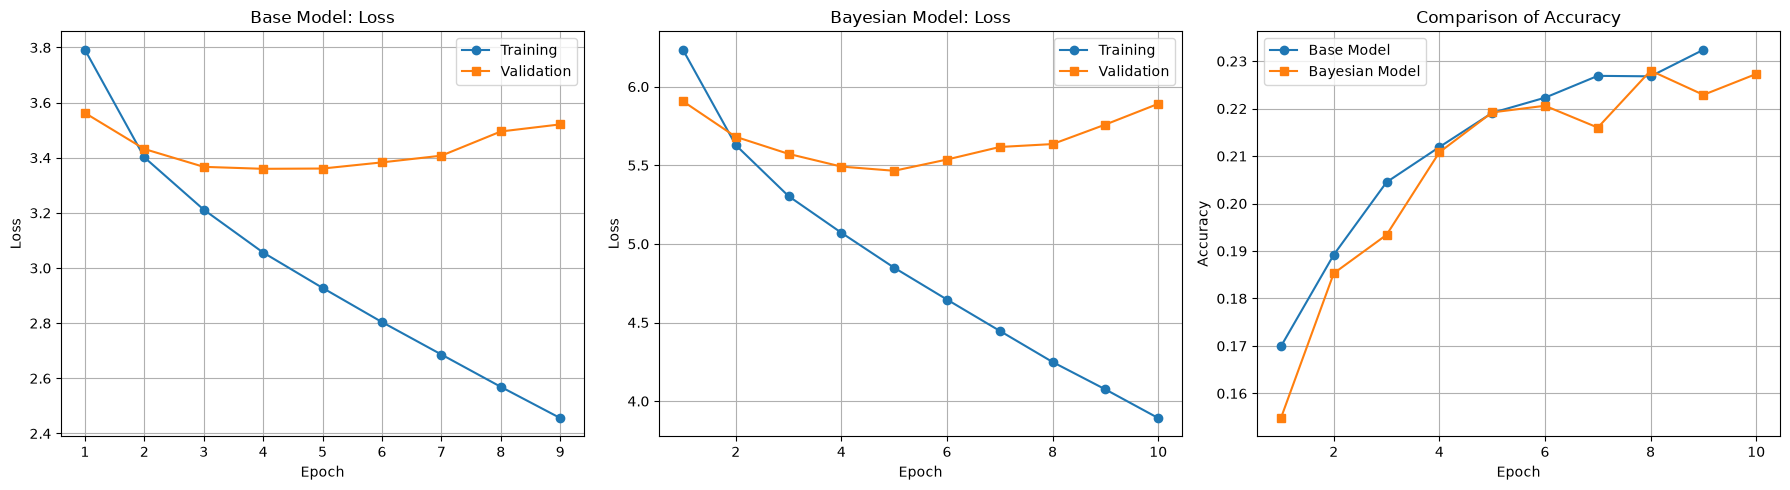

In [17]:
num_epochs = 15  # Define the number of epochs for training.
patience = 5  # Define the patience for early stopping.

# Define the loss function, optimizer, and device for training.
loss_fn = nn.CrossEntropyLoss()  # Define the loss function for classification tasks.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Set the device to GPU if available, otherwise CPU.
# Print the device being used for training.
print(f"Using device: {device} + Version: {torch.__version__} + Version Info: {torch.version.cuda}")

# Train the base model (only fine labels) and the Bayesian model (fine + coarse labels).
model_base = CIFAR100_Model()
# Define the optimizer (Adam) with a learning rate of 0.001.
# weight_decay=1e-4 is added to the optimizer to apply L2 regularization, which helps prevent overfitting by penalizing large weights in the model.
optimizer_base = optim.Adam(model_base.parameters(), lr=0.001, weight_decay=1e-4)  

print("--- Training Base Model (Only Fine) ---")
model_base, base_train_loss, base_val_loss,base_accuracy = train_model_base(
    model_base, 
    train_loader, 
    loss_fn, 
    optimizer_base, epochs=num_epochs, device=device, patience=patience)

# Train the Bayesian model (fine + coarse labels).
model_bayes = CIFAR100_Model()
# Define the optimizer (Adam) with a learning rate of 0.001.
# weight_decay=1e-4 is added to the optimizer to apply L2 regularization, which helps prevent overfitting by penalizing large weights in the model.
optimizer_bayes = optim.Adam(model_bayes.parameters(), lr=0.001, weight_decay=1e-4)

print("\n--- Training Bayesian Model (Fine + Coarse) ---")
model_bayes, bayes_train_loss, bayes_val_loss, bayes_accuracy = train_model_bayes(
    model_bayes,
    train_loader, 
    loss_fn, 
    optimizer_bayes, coarse_mapping=coarse_mapping, epochs=num_epochs, device=device, patience=patience)

# Training stops a bit between each epoch because of the validation phase.

# Adjusting automatically to the number of epochs used in training.
epochs_base = range(1, len(base_train_loss) + 1)
epochs_bayes = range(1, len(bayes_train_loss) + 1)
plt.figure(figsize=(18, 5))  # Set the figure size for the plots.

# Graph 1: Loss for Base Model
plt.subplot(1, 3, 1)
plt.plot(epochs_base, base_train_loss, label='Training', marker='o')
plt.plot(epochs_base, base_val_loss, label='Validation', marker='s')
plt.title('Base Model: Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Graph 2: Loss for Bayesian Model
plt.subplot(1, 3, 2)
plt.plot(epochs_bayes, bayes_train_loss, label='Training', marker='o')
plt.plot(epochs_bayes, bayes_val_loss, label='Validation', marker='s')
plt.title('Bayesian Model: Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Graph 3: Accuracy
plt.subplot(1, 3, 3)
plt.plot(epochs_base, base_accuracy, label='Base Model', marker='o')
plt.plot(epochs_bayes, bayes_accuracy, label='Bayesian Model', marker='s')
plt.title('Comparison of Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
print("FINAL EXAM WITH DATA OF THE TEST SET.")

model_base.eval()  # Set the base model to evaluation mode. 
model_bayes.eval()  # Set the Bayesian model to evaluation mode.
base_good_predictions = 0  # Initialize a counter for correct predictions for the base model.
bayes_good_predictions = 0  # Initialize a counter for correct predictions for the Bayesian model.
total_predictions = 0  # Initialize a counter for total predictions for the base model.

with torch.no_grad():  # Disable gradient calculation for evaluation.
    for images, fine_labels in test_loader:
        images = images.to(device)  # Move images to the specified device.
        fine_labels = fine_labels.to(device)  # Move fine labels to the specified device.

        # Get predictions from the Base model.
        _, fine_pred_base = model_base(images)  # Get predictions from the base model.
        predicted_labels_base = torch.argmax(fine_pred_base, dim=1)  # Get the predicted labels for the base model.
        base_good_predictions += (predicted_labels_base == fine_labels).sum().item()

        # Get predictions from the Bayesian model.
        coarse_pred_bayes, fine_pred_bayes = model_bayes(images)  # Get predictions from the Bayesian model.
        # Combine the predictions from both models using Bayes' theorem.
        final_prob = F.softmax(fine_pred_bayes, dim=1) * F.softmax(coarse_pred_bayes, dim=1)[:, coarse_mapping]
        # Calculate the predicted labels for the Bayesian model by taking the argmax of the final probabilities.
        pred_bayes = torch.argmax(final_prob, dim=1)
        # Count correct predictions for the Bayesian model by comparing predicted labels with true fine labels.
        bayes_good_predictions += (pred_bayes == fine_labels).sum().item()

        total_predictions += fine_labels.size(0)  # Update the total number of predictions.

print(f"Accuracy Final Base (Test):  {(base_good_predictions/total_predictions)*100:.2f}%")
print(f"Accuracy Final Bayes (Test): {(bayes_good_predictions/total_predictions)*100:.2f}%")

FINAL EXAM WITH DATA OF THE TEST SET.
Accuracy Final Base (Test):  23.24%
Accuracy Final Bayes (Test): 22.73%
